In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [5]:
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].mode()[0])

In [6]:
df.isnull().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['academic_work_impact'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
df.drop(['transaction_id', 'user_id'], axis=1, inplace=True)
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [10]:
df.to_csv('Smartphone_Cleaned.csv', index=False)

In [11]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


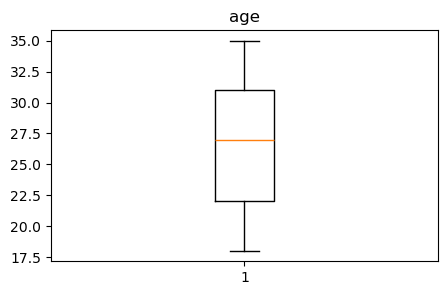

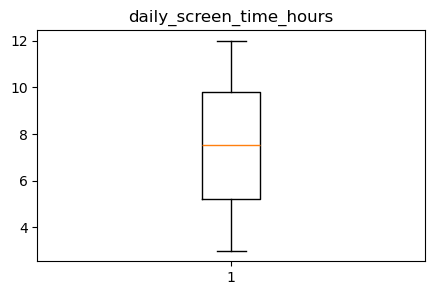

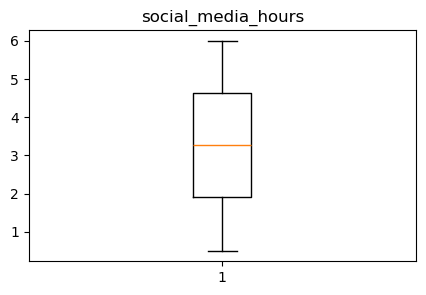

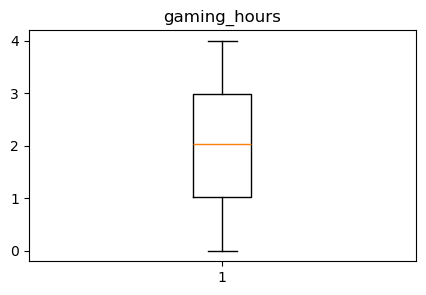

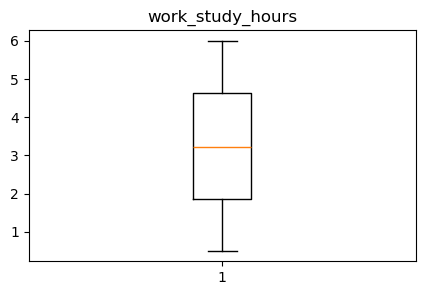

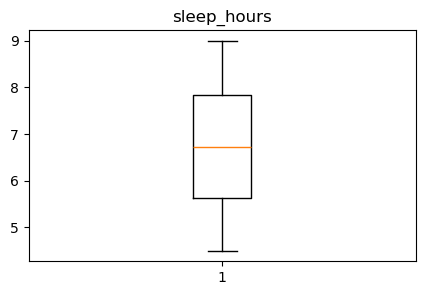

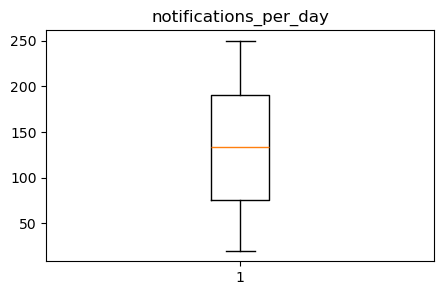

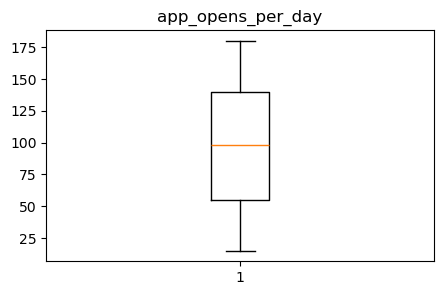

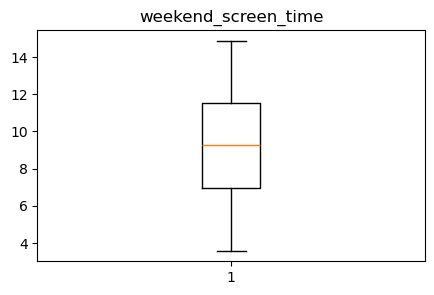

In [12]:
numeric_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

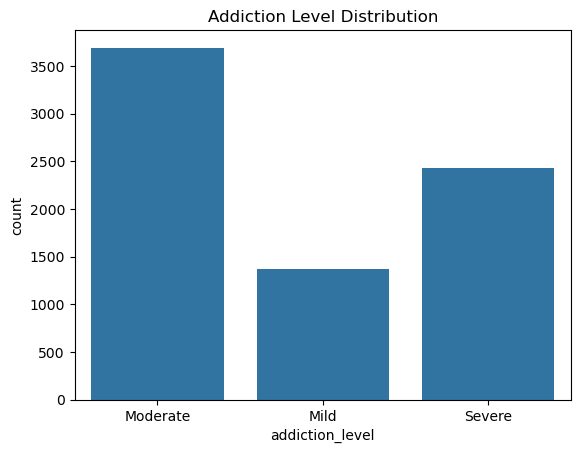

In [13]:
sns.countplot(x='addiction_level', data=df)
plt.title('Addiction Level Distribution')
plt.show()

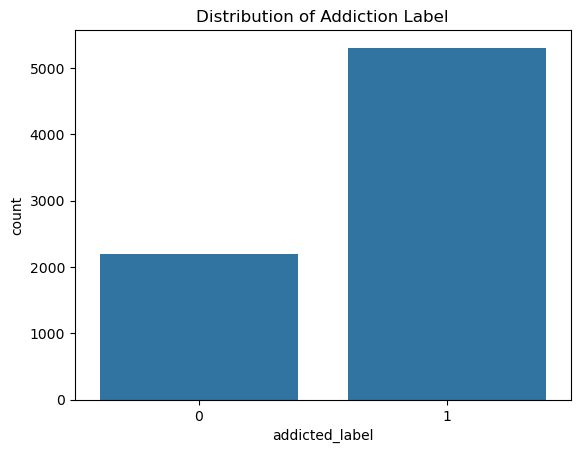

In [14]:
sns.countplot(x='addicted_label', data=df)
plt.title('Distribution of Addiction Label')
plt.show()

### Histograms

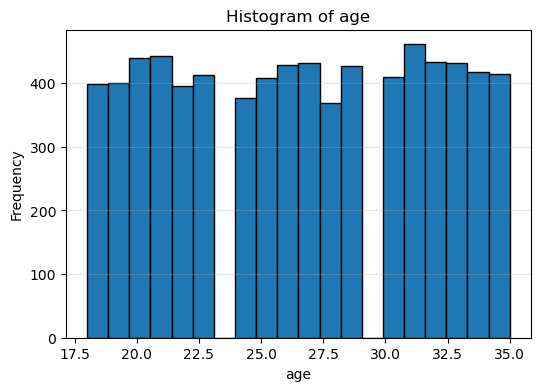

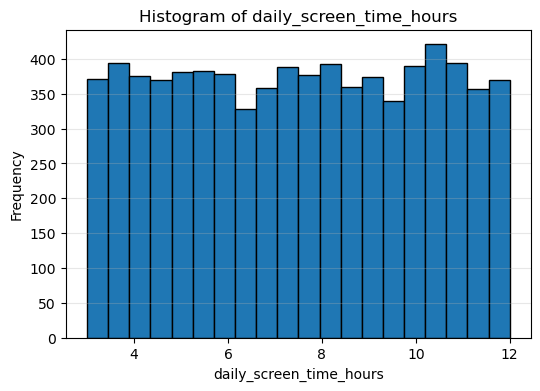

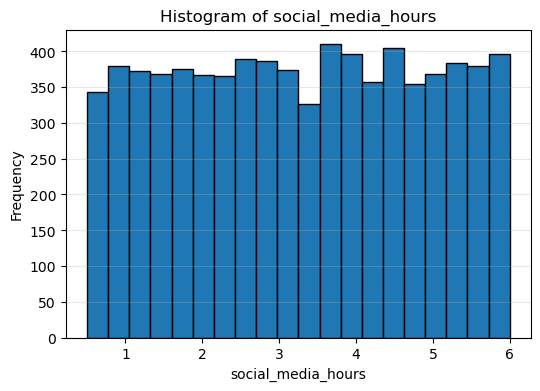

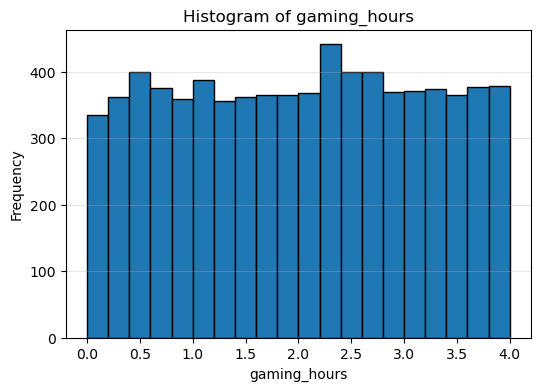

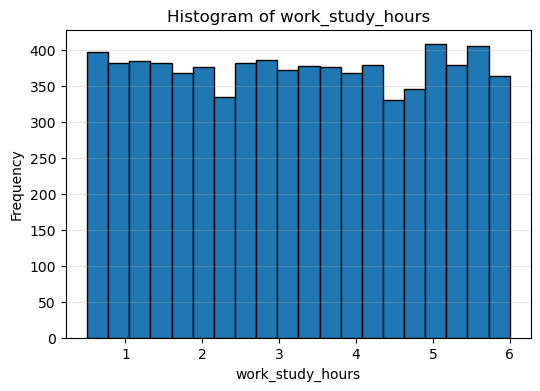

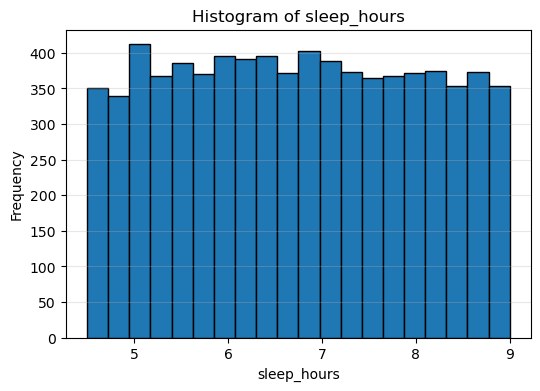

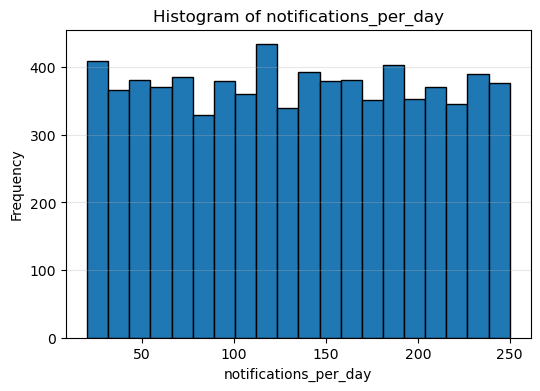

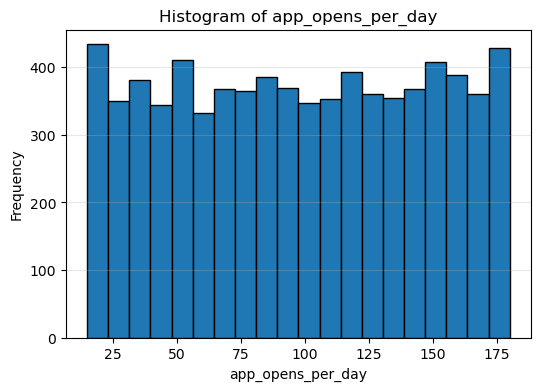

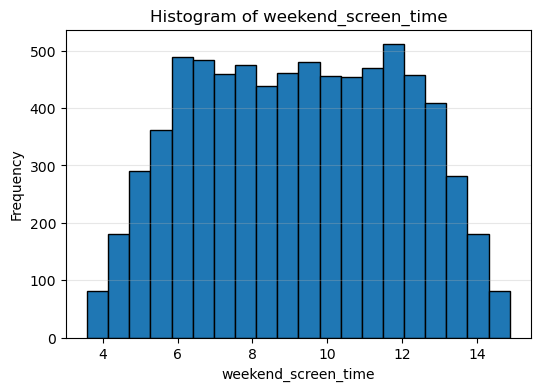

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

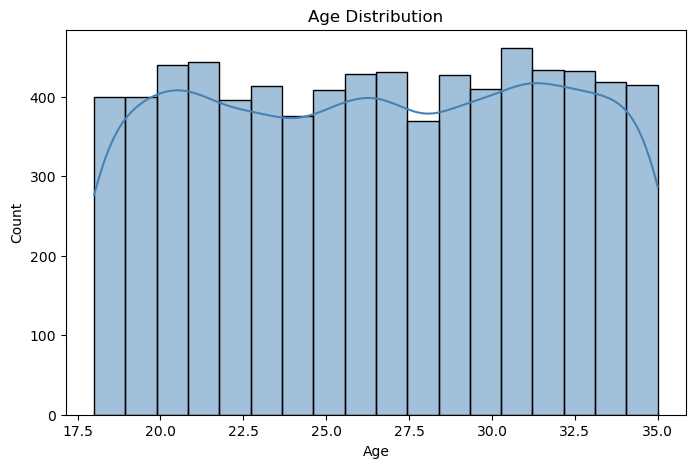

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=18, kde=True, color='steelblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [17]:
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['academic_work_impact'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})
df['addiction_level'] = df['addiction_level'].map({'Mild': 0, 'Moderate': 1, 'Severe': 2})

df = pd.get_dummies(df, columns=['gender'], prefix='gender', drop_first=True)

df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,gender_Male,gender_Other
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,1,0,True,False
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,1,0,False,True
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0,False,True
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,1,False,True
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2,1,True,False


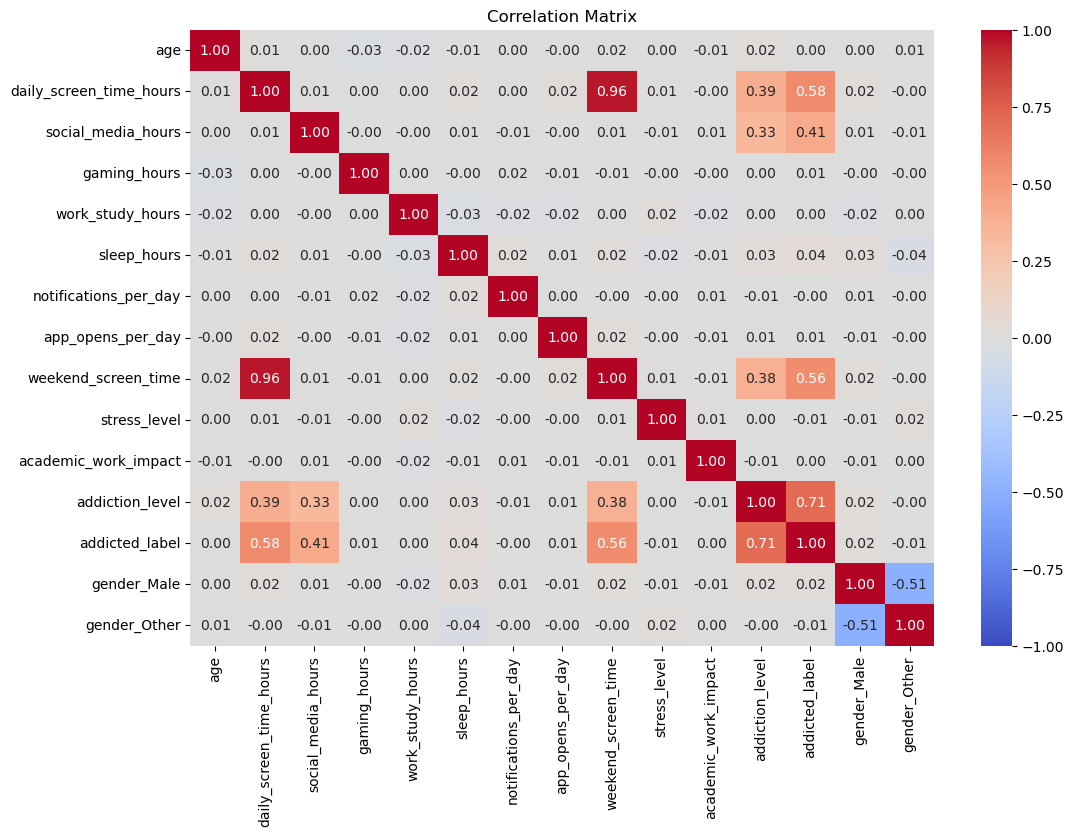

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [19]:
df['social_ratio'] = df['social_media_hours'] / df['daily_screen_time_hours']
df['screen_sleep_ratio'] = df['daily_screen_time_hours'] / df['sleep_hours']
df['weekend_difference'] = df['weekend_screen_time'] - df['daily_screen_time_hours']

df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,gender_Male,gender_Other,social_ratio,screen_sleep_ratio,weekend_difference
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,1,0,True,False,0.622291,0.427815,0.72
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,1,0,False,True,0.748527,0.664491,1.62
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0,False,True,0.224422,1.231707,2.62
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,1,False,True,0.747126,0.951397,1.94
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2,1,True,False,0.594378,1.603865,2.59


In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(['addicted_label', 'addiction_level'], axis=1)
y = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (6000, 16)
X_test : (1500, 16)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Male,gender_Other,social_ratio,screen_sleep_ratio,weekend_difference
5171,0.845647,-0.890757,0.566001,0.317139,0.538647,1.238562,1.161997,-1.167484,-1.213161,-0.005663,1.003339,-0.720408,-0.701810,0.887387,-1.147886,-1.351359
6534,1.037869,0.830243,1.333188,-0.371107,0.213916,-0.631536,0.232537,1.491283,0.437582,1.207927,1.003339,-0.720408,1.424887,0.159770,1.024659,-1.351359
1737,-0.307683,0.826402,-0.955797,-0.144596,-1.172436,0.911295,-1.026731,1.140903,1.126620,-1.219254,1.003339,1.388103,-0.701810,-0.950268,0.142822,1.257898
3749,0.845647,-0.210809,0.427655,-0.423379,-0.747788,0.030790,0.682276,-0.487334,-0.627295,1.207927,1.003339,-0.720408,1.424887,0.189832,-0.278258,-1.601182
63,-1.268791,-0.933014,0.597443,1.240609,0.301343,-1.675675,1.206971,-0.301839,-0.822583,-1.219254,-0.996672,-0.720408,-0.701810,0.967983,-0.108201,0.272487


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_train_scaled.columns[selector.get_support()]
print(selected_features)
print(len(selected_features))

Index(['daily_screen_time_hours', 'social_media_hours', 'sleep_hours',
       'weekend_screen_time', 'gender_Male', 'gender_Other', 'social_ratio',
       'screen_sleep_ratio'],
      dtype='object')
8


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print("Original Features:", X_train_selected.shape[1])
print("Selected Components:", pca.n_components_)

pca_train_df = pd.DataFrame(
    X_train_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
pca_train_df.head()

Original Features: 8
Selected Components: 5


,PC1,PC2,PC3,PC4,PC5
0,-2.250258,0.105098,-0.061310,1.008950,-0.984380
1,1.026245,-0.498971,2.221783,0.007049,0.478735
2,1.504608,0.906929,-1.722545,0.771174,0.483250
3,-0.692611,-1.207448,0.931866,0.222820,0.505568
4,-1.290803,0.225924,1.005605,-1.701247,-1.009174


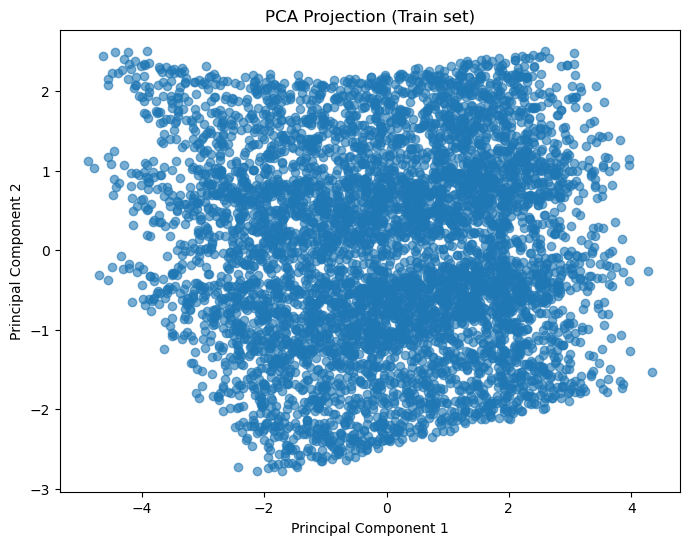

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (Train set)")
plt.show()

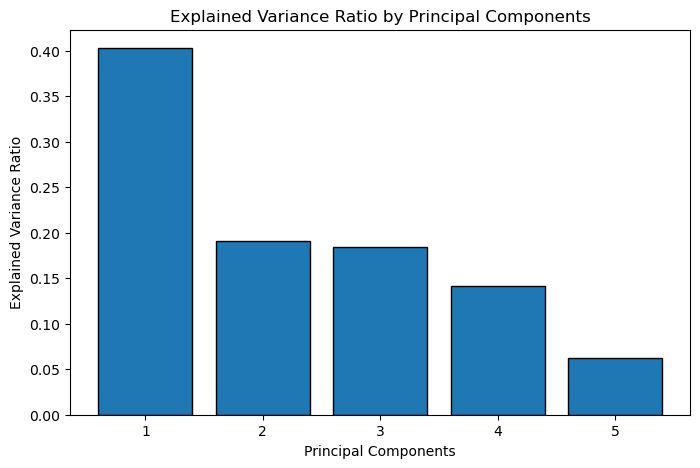

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    edgecolor='black'
)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by Principal Components")
plt.show()

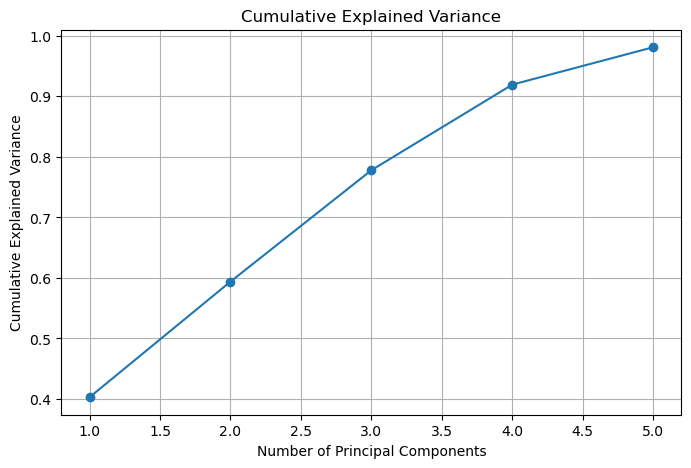

In [26]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

### Logistic Regression

Train Accuracy: 0.8985
Test Accuracy : 0.8953333333333333
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       438
           1       0.91      0.94      0.93      1062

    accuracy                           0.90      1500
   macro avg       0.88      0.86      0.87      1500
weighted avg       0.89      0.90      0.89      1500



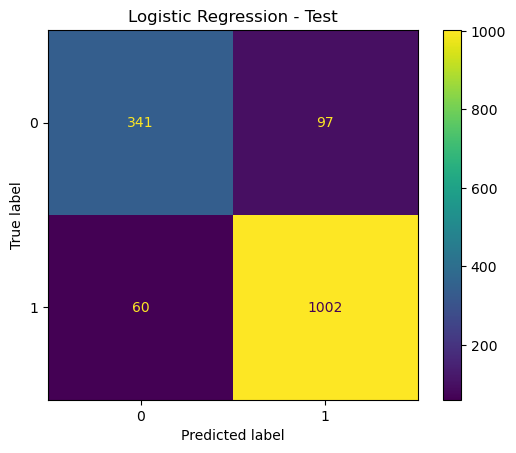

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_pca, y_train)

lr_train_pred = lr_model.predict(X_train_pca)
lr_test_pred = lr_model.predict(X_test_pca)

print("Train Accuracy:", accuracy_score(y_train, lr_train_pred))
print("Test Accuracy :", accuracy_score(y_test, lr_test_pred))
print(classification_report(y_test, lr_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, lr_test_pred)
plt.title("Logistic Regression - Test")
plt.show()

### KNN

Train Accuracy: 0.9428333333333333
Test Accuracy : 0.9193333333333333
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       438
           1       0.94      0.94      0.94      1062

    accuracy                           0.92      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.92      0.92      0.92      1500



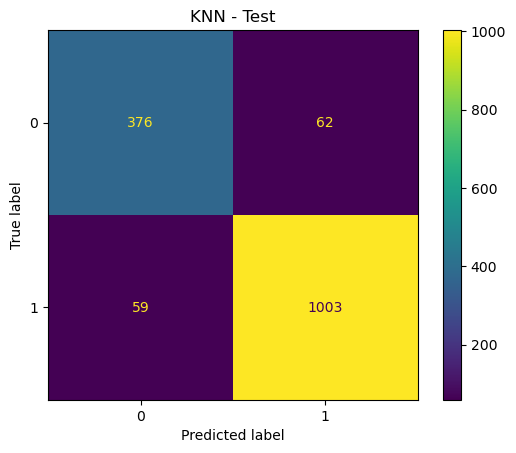

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train)

knn_train_pred = knn_model.predict(X_train_pca)
knn_test_pred = knn_model.predict(X_test_pca)

print("Train Accuracy:", accuracy_score(y_train, knn_train_pred))
print("Test Accuracy :", accuracy_score(y_test, knn_test_pred))
print(classification_report(y_test, knn_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, knn_test_pred)
plt.title("KNN - Test")
plt.show()

### Decision Tree

Train Accuracy: 0.9563333333333334
Test Accuracy : 0.916
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       438
           1       0.93      0.95      0.94      1062

    accuracy                           0.92      1500
   macro avg       0.90      0.89      0.90      1500
weighted avg       0.92      0.92      0.92      1500



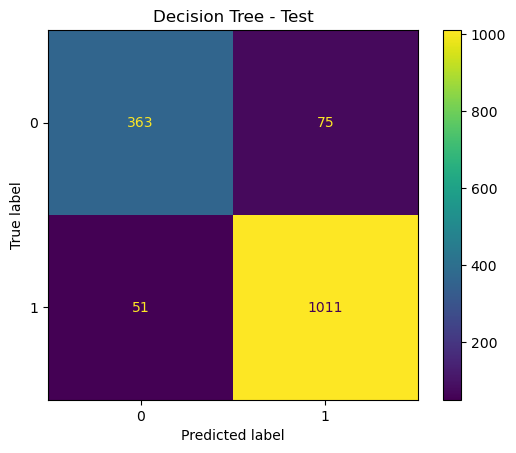

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_pca, y_train)

dt_train_pred = dt_model.predict(X_train_pca)
dt_test_pred = dt_model.predict(X_test_pca)

print("Train Accuracy:", accuracy_score(y_train, dt_train_pred))
print("Test Accuracy :", accuracy_score(y_test, dt_test_pred))
print(classification_report(y_test, dt_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, dt_test_pred)
plt.title("Decision Tree - Test")
plt.show()

### Random Forest

Train Accuracy: 0.9625
Test Accuracy : 0.9186666666666666
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       438
           1       0.94      0.94      0.94      1062

    accuracy                           0.92      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.92      0.92      0.92      1500



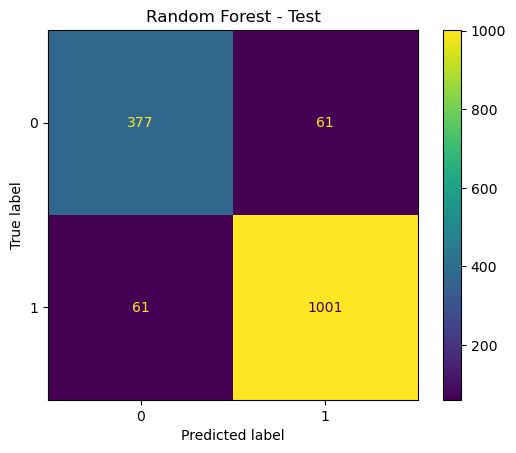

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=100,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train_pca, y_train)

rf_train_pred = rf_model.predict(X_train_pca)
rf_test_pred = rf_model.predict(X_test_pca)

print("Train Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Test Accuracy :", accuracy_score(y_test, rf_test_pred))
print(classification_report(y_test, rf_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_test_pred)
plt.title("Random Forest - Test")
plt.show()

### SVM

Train Accuracy: 0.9251666666666667
Test Accuracy : 0.9233333333333333
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       438
           1       0.94      0.95      0.95      1062

    accuracy                           0.92      1500
   macro avg       0.91      0.90      0.91      1500
weighted avg       0.92      0.92      0.92      1500



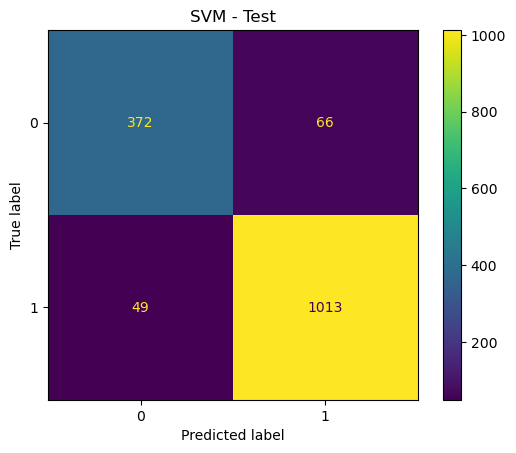

In [31]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_pca, y_train)

svm_train_pred = svm_model.predict(X_train_pca)
svm_test_pred = svm_model.predict(X_test_pca)

print("Train Accuracy:", accuracy_score(y_train, svm_train_pred))
print("Test Accuracy :", accuracy_score(y_test, svm_test_pred))
print(classification_report(y_test, svm_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, svm_test_pred)
plt.title("SVM - Test")
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}")
    print(f"Fold Accuracies: {scores}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print("-" * 40)

Logistic Regression
Fold Accuracies: [0.92416667 0.88583333 0.90583333 0.89416667 0.88583333]
Mean Accuracy: 0.8992
----------------------------------------
KNN
Fold Accuracies: [0.93       0.9        0.92       0.91       0.90583333]
Mean Accuracy: 0.9132
----------------------------------------
Decision Tree
Fold Accuracies: [0.9175     0.89166667 0.9175     0.90666667 0.8925    ]
Mean Accuracy: 0.9052
----------------------------------------
Random Forest
Fold Accuracies: [0.93333333 0.91333333 0.92833333 0.91916667 0.91583333]
Mean Accuracy: 0.9220
----------------------------------------
SVM
Fold Accuracies: [0.93083333 0.90166667 0.92666667 0.92416667 0.91166667]
Mean Accuracy: 0.9190
----------------------------------------


In [33]:
cv_df = pd.DataFrame(cv_results.items(), columns=["Model", "CV Accuracy"])
cv_df = cv_df.sort_values(by="CV Accuracy", ascending=False).reset_index(drop=True)
cv_df["CV Accuracy"] = cv_df["CV Accuracy"].round(4)
print(cv_df)

                 Model  CV Accuracy
0        Random Forest       0.9220
1                  SVM       0.9190
2                  KNN       0.9132
3        Decision Tree       0.9052
4  Logistic Regression       0.8992


In [34]:
results = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "SVM"],
    "Train Accuracy": [
        accuracy_score(y_train, lr_train_pred),
        accuracy_score(y_train, knn_train_pred),
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        accuracy_score(y_train, svm_train_pred)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, lr_test_pred),
        accuracy_score(y_test, knn_test_pred),
        accuracy_score(y_test, dt_test_pred),
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, svm_test_pred)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Train Accuracy  Test Accuracy
0  Logistic Regression        0.898500       0.895333
1                  KNN        0.942833       0.919333
2        Decision Tree        0.956333       0.916000
3        Random Forest        0.962500       0.918667
4                  SVM        0.925167       0.923333


In [35]:
best_model_name = cv_df.loc[cv_df["CV Accuracy"].idxmax(), "Model"]
best_accuracy = cv_df["CV Accuracy"].max()

print("=" * 40)
print(f"Best Model: {best_model_name}")
print(f"Best CV Accuracy: {best_accuracy:.4f}")
print("=" * 40)

Best Model: Random Forest
Best CV Accuracy: 0.9220


In [37]:
models_dict = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

best_model = models_dict[best_model_name]

print("Selected Best Model:", best_model_name)

Selected Best Model: Random Forest


In [40]:
def predict_new_user(raw_input: dict, model=None, actual_label=None):
    if model is None:
       model = best_model
    """
    raw_input: dict with the RAW (unencoded) columns, e.g.:
        {
            'age': 24,
            'gender': 'Female',                
            'daily_screen_time_hours': 8.5,
            'social_media_hours': 4.2,
            'gaming_hours': 1.5,
            'work_study_hours': 3.0,
            'sleep_hours': 6.0,
            'notifications_per_day': 160,
            'app_opens_per_day': 110,
            'weekend_screen_time': 10.5,
            'stress_level': 'High',            
            'academic_work_impact': 'Yes'       
    model: a trained classifier (default: rf_model, the best model)
    actual_label: optional int (0/1) if you know the real label, to check correctness
    """
    row = pd.DataFrame([raw_input])

    row['stress_level'] = row['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
    row['academic_work_impact'] = row['academic_work_impact'].map({'No': 0, 'Yes': 1})

    row['social_ratio'] = row['social_media_hours'] / row['daily_screen_time_hours']
    row['screen_sleep_ratio'] = row['daily_screen_time_hours'] / row['sleep_hours']
    row['weekend_difference'] = row['weekend_screen_time'] - row['daily_screen_time_hours']

    row = pd.get_dummies(row, columns=['gender'], prefix='gender')

    row = row.reindex(columns=X_train.columns, fill_value=False)

    row_scaled = pd.DataFrame(scaler.transform(row), columns=row.columns)
    row_selected = selector.transform(row_scaled)
    row_pca = pca.transform(row_selected)

    prediction = model.predict(row_pca)[0]
    label_text = "Addicted" if prediction == 1 else "Not Addicted"

    print(f"Predicted label: {prediction} ({label_text})")

    if actual_label is not None: 
        actual_text = "Addicted" if actual_label == 1 else "Not Addicted"
        is_correct = (prediction == actual_label)
        print(f"Actual label:    {actual_label} ({actual_text})")
        print(f"Correct prediction: {is_correct}")

    return prediction

In [41]:
sample_user = {
    'age': 20,
    'gender': 'Female',
    'daily_screen_time_hours': 9.5,
    'social_media_hours': 5.2,
    'gaming_hours': 2.0,
    'work_study_hours': 2.0,
    'sleep_hours': 5.5,
    'notifications_per_day': 150,
    'app_opens_per_day': 100,
    'weekend_screen_time': 13.0,
    'stress_level': 'Low',
    'academic_work_impact': 'No'
}

predict_new_user(sample_user, model=best_model,actual_label=0)

Predicted label: 1 (Addicted)
Actual label:    0 (Not Addicted)
Correct prediction: False


np.int64(1)